In [1]:
import h5py
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
from matplotlib.offsetbox import AnchoredText

import lmfit
from dataclasses import dataclass
from uncertainties import ufloat
from uncertainties import unumpy as unp 

from IPython.display import display, Math, Latex

In [2]:
h5_path = '../calib_data/CalibrationData2024.h5'

In [3]:
def _apply_pub_style():
    """Set matplotlib rcParams for a clean, publication-ready style."""
    mpl.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 200,
        "font.size": 10,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "figure.constrained_layout.use": True,
    })
    
    
def _pi_over_two_formatter(x, pos):
    # multiple of (π/2)
    k = x / (np.pi / 2)
    n = int(np.round(k))
    
    if not np.isclose(k, n):
        return ""
    if n == 0:
        return r"$0$"
    
    sign = "-" if n < 0 else ""
    a = abs(n)

    if a % 2 == 0:
        # even multiples → m * π
        m = a // 2
        if m == 1: return fr"${sign}\pi$"
        else: return fr"${sign}{m}\pi$"
    else:
        # odd multiples → (m) * π/2
        if a == 1:
            return fr"${sign}\pi/2$"
        else:
            return fr"${sign}{a}\pi/2$"

In [4]:
def plot_data(
    frequency_hz: np.ndarray,
    amplitude: np.ndarray,
    amplitude_error: np.ndarray,
    phase_deg: np.ndarray,
    phase_error: np.ndarray
) -> plt.Figure:
    """Generates scatter plots of amplitude and phase vs frequency in separate subplots."""
    _apply_pub_style()
    
    fig = plt.figure(figsize=(6.4, 4.8))  # ~ 6.4x4.8 inches
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

    # Amplitude
    ax0.errorbar(frequency_hz, amplitude, yerr=amplitude_error, linestyle="none", marker="o", markersize=3)
    ax0.set_ylabel(r"$\left| H^{vc}_{x} \right|  \; (\mu\mathrm{m}/\mathrm{V})$")
    ax0.tick_params(labelbottom=False)

    # Phase
    ax1.errorbar(frequency_hz, phase_deg, yerr=phase_error, linestyle="none", marker="o", markersize=3, label="Data")
    ax1.set_ylabel(r"$\phi^{vc}_{x}$ (rad)")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.yaxis.set_major_locator(MultipleLocator(base=np.pi/2))
    ax1.yaxis.set_major_formatter(FuncFormatter(_pi_over_two_formatter))
    
    fig.suptitle("Voice Coil Calibration Data")

    return fig

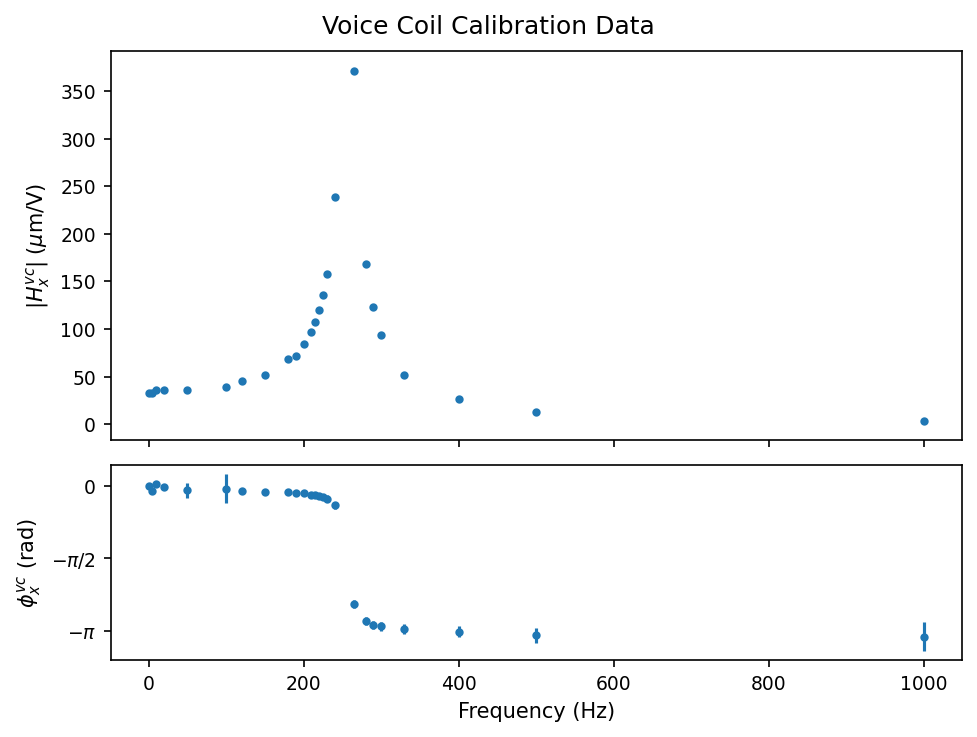

In [5]:
with h5py.File(h5_path, 'r') as f:
    frequency = np.array(f['Frequency'])
    amplitude = np.array(f['A'])
    amplitude_error = np.array(f['AUncertainty'])
    phase = np.array(f['Phase'])
    phase_error = np.array(f['PhaseUncertainty'])
    
    plot_data(frequency, amplitude, amplitude_error, phase, phase_error)

In [6]:
@dataclass
class CalibrationParams:
    """Calibration parameters for the coil driver.

    Attributes:
        f0: Resonant frequency in Hz
        Q: Quality factor, equivalent to 1/(2ζ_m)
        k: Gain factor, equivalent to α/k_m
        c: Phase offset in rad
    """
    f0: ufloat 
    Q: ufloat  
    k: ufloat 
    c: ufloat

def magnitude_func(
    f: np.ndarray, 
    f0: float, 
    Q: float, 
    k: float
) -> np.ndarray:
    return (k * f0**2) / np.sqrt((f0**2 - f**2)**2 + f0**2*f**2/Q**2)

def phase_func(
    f: np.ndarray, 
    f0: float, 
    Q: float,
    c: float
) -> np.ndarray:
    return np.arctan2(f0/Q*f, f**2 - f0**2) + c

def mag_phase_funcs(
    f: np.ndarray, 
    f0: float, 
    Q: float, 
    k: float, 
    c: float
) -> np.ndarray:
    """
    Args:
        f: Frequency array in Hz 
        f0: Resonant frequency in Hz
        Q: Quality factor, equivalent to 1/(2ζ_m)
        k: Gain factor, equivalent to α/k_m
    """
    mag = magnitude_func(f, f0, Q, k)
    phase = phase_func(f, f0, Q, c)
    return np.append(mag, phase)

def fit_data(
    frequency_hz: np.ndarray,
    amplitude: np.ndarray,
    amplitude_error: np.ndarray,
    phase_deg: np.ndarray,
    phase_error: np.ndarray,
) -> CalibrationParams:
    model = lmfit.Model(mag_phase_funcs, weights=np.append(1/amplitude_error, 1/phase_error), scale_covar=False)
    params = model.make_params(f0=1, Q=dict(value=1, min=0), k=1, c=0)
    f_tot = frequency_hz
    y_tot = np.append(amplitude, phase_deg)
    result = model.fit(y_tot, params, f=f_tot)

    return CalibrationParams(f0=result.uvars['f0'], 
                             Q=result.uvars['Q'], 
                             k=result.uvars['k'],
                             c=result.uvars['c'],)

def make_param_rows(params, u_digits: int = 1):
    """Return [[label, value], ...] with LaTeX labels and UFloat '(±)' style."""
    fspec = f".{u_digits}uSL"  # e.g. '.1uSL' -> 257.24(9)
    return [
        [r"$f_0$ (Hz)",                     f"{params.f0:{fspec}}"],
        [r"$Q = (2\,\zeta_{\mathrm{m}})^{-1}$", f"{params.Q:{fspec}}"],
        [r"$K = \alpha/k_{\mathrm{m}}$",    f"{params.k:{fspec}}"],
        [r"$c$ (rad)",                      f"{params.c:{fspec}}"],
    ]

In [7]:
def plot_fit(
    params,
    frequency_hz: np.ndarray,
    amplitude: np.ndarray,
    amplitude_error: np.ndarray,
    phase_deg: np.ndarray,
    phase_error: np.ndarray,
) -> plt.Figure:
    """Fit plots (left 2 rows) + fit parameter table (right spanning both rows)."""
    _apply_pub_style()

    # 2 rows x 2 cols; right column is the table spanning both rows
    fig = plt.figure(figsize=(6.4, 4.8))  # ~ 6.4x4.8 inches
    gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0.05)

    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[1, 0], sharex=ax0)

    fit_freq = np.geomspace(frequency_hz.min(), frequency_hz.max(), 1000)

    # --- Amplitude ---
    ax0.errorbar(frequency_hz, amplitude, yerr=amplitude_error,
                 marker="o", ms=3, capsize=2, linestyle='none')
    ax0.plot(fit_freq, magnitude_func(fit_freq, 
                                      unp.nominal_values(params.f0), 
                                      unp.nominal_values(params.Q), 
                                      unp.nominal_values(params.k)))
    ax0.set_ylabel(r"$\left| H^{vc}_{x} \right|$ (µm/V)")
    ax0.tick_params(labelbottom=False)
    ax0.loglog()
    ax0.text(0.03, 0.95, "(a)", transform=ax0.transAxes, ha="left", va="top")
    eq0 = r"$\left| H^{vc}_{x} (f)\right| = \frac{K f_0^2}{\sqrt{(f_0^2 - f^2)^2 + \frac{f_0^2}{Q^2}f^2}}$"
    ax0.text(
        3, 8, eq0,                       # x=30 Hz, y=-1 rad (your choice)
        transform=ax0.transData,            # <-- data coordinates
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6", alpha=0.9)
    )

    # --- Phase ---
    ax1.errorbar(frequency_hz, phase_deg, yerr=phase_error,
                 marker="o", ms=3, capsize=2, linestyle='none')
    ax1.plot(fit_freq, phase_func(fit_freq, 
                                  unp.nominal_values(params.f0), 
                                  unp.nominal_values(params.Q), 
                                  unp.nominal_values(params.c)))
    ax1.set_ylabel(r"$\phi^{vc}_{x}$ (rad)")
    ax1.set_xlabel("Frequency (Hz)")
    ax1.yaxis.set_major_locator(MultipleLocator(base=np.pi/2))
    ax1.yaxis.set_major_formatter(FuncFormatter(_pi_over_two_formatter))
    ax1.text(0.03, 0.22, "(b)", transform=ax1.transAxes, ha="left", va="top")
    eq1 = r"$\phi^{vc}_{x}(f) = \mathrm{atan2} \left( \frac{\frac{f_0}{Q} f}{f^2 - f_0^2} \right) + c$"
    ax1.text(
        3, -1.5, eq1,                       # x=30 Hz, y=-1 rad (your choice)
        transform=ax1.transData,            # <-- data coordinates
        ha="left", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6", alpha=0.9)
    )


    fig.suptitle("Voice Coil Transfer Function Joint Fit of Amplitude and Phase", y=1.05)
    return fig

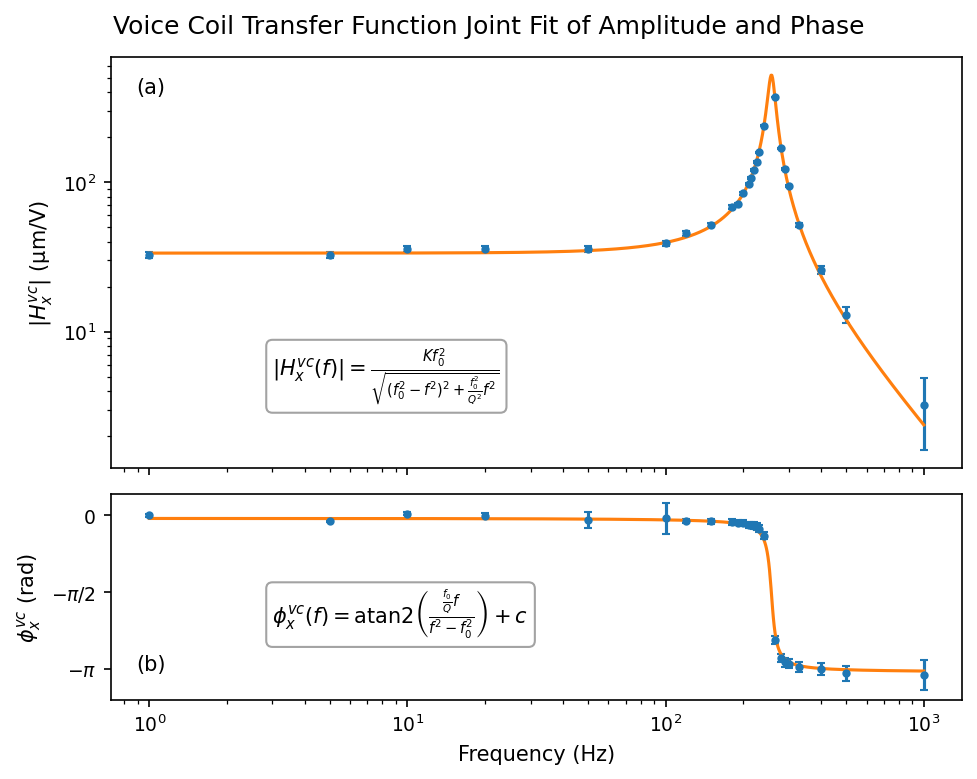

In [8]:
with h5py.File(h5_path, 'r') as f:
    frequency = np.array(f['Frequency'])
    amplitude = np.array(f['A'])
    amplitude_error = np.array(f['AUncertainty'])
    phase = np.array(f['Phase'])
    phase_error = np.array(f['PhaseUncertainty'])
    
    params = fit_data(frequency, amplitude, amplitude_error, phase, phase_error)
    plot_fit(params, frequency, amplitude, amplitude_error, phase, phase_error)

In [9]:
rows = make_param_rows(params, u_digits=1)
for k, v in rows:
    display(Latex(f"{k}: {v}"))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>